# AV1 — Importação, preparação e análise exploratória de dados

**Ciência de Dados | Avaliação individual | Valor: 5,0 pontos**

Você trabalhará com a base didática **Imóveis para locação em Maceió**. Cada linha descreve um anúncio e `aluguel_mensal_brl` é a variável central. A base é sintética: foi criada apenas para ensino e não representa imóveis ou anúncios reais.

Esta avaliação reproduz as competências dos notebooks:

- `Importacao_Inspecao_Pandas`;
- `Limpeza_Preparacao`;
- `EDA`.

> **Regra de evidência:** saída sem código, código sem interpretação e afirmação sem número/tabela/gráfico não recebem pontuação integral.


## Instruções e entrega

1. Execute as células na ordem.
2. Preencha todas as células marcadas com **SUA RESPOSTA**.
3. Preserve a base bruta em `df_original`; faça transformações em cópias.
4. Não apague erros, casos estranhos ou limitações: explique suas decisões.
5. Antes de entregar, use **Reiniciar ambiente e executar tudo**.
6. Renomeie o notebook para `AV1_Nome_Matricula.ipynb`.
7. Entregue o notebook com saídas e os CSVs solicitados.

### Declaração de autoria e ferramentas

Preencha a declaração com `nenhuma` ou descreva objetivamente qualquer ferramenta externa utilizada. O uso permitido de IA segue a orientação dada pelo professor. Você deve conseguir explicar oralmente qualquer linha entregue.

### Distribuição dos pontos

| Parte | Conteúdo | Pontos |
|---|---|---:|
| A | Importação, inspeção e diagnóstico | 1,0 |
| B | Limpeza e preparação rastreável | 1,5 |
| C | EDA e interpretação | 2,0 |
| D | Evidências de execução e reprodutibilidade | 0,5 |


## Identificação

Preencha os três campos. A matrícula será usada apenas para gerar uma amostra individual reproduzível.


In [1]:
NOME_COMPLETO = "João Gabriel Cavalcante de Oliveira Santos"
MATRICULA = "2025102151"
DECLARACAO_USO_IA = "Utilização de assistente de IA para validação de sintaxe e interpretação."

digitos_matricula = "".join(caractere for caractere in MATRICULA if caractere.isdigit())
assert NOME_COMPLETO.strip(), "Preencha NOME_COMPLETO."
assert len(digitos_matricula) >= 4, "Preencha uma matrícula válida."
assert DECLARACAO_USO_IA.strip(), "Preencha a declaração de ferramentas."

SEMENTE_INDIVIDUAL = int(digitos_matricula[-8:]) % (2**32 - 1)
print("Aluno(a):", NOME_COMPLETO)
print("Matrícula:", MATRICULA)
print("Semente individual:", SEMENTE_INDIVIDUAL)


Aluno(a): João Gabriel Cavalcante de Oliveira Santos
Matrícula: 2025102151
Semente individual: 25102151


# Parte A — Importação, inspeção e diagnóstico (1,0 pontos)

## A1. Ambiente e carregamento correto (0,20)

Importe `Path`, `StringIO`, `hashlib`, `sqlite3`, `numpy`, `pandas`, `matplotlib.pyplot`, `seaborn` e `stats` de `scipy`. Carregue a base em `df_original`.

Requisitos:

- procure `dados/imoveis_locacao_maceio.csv`, `../dados/imoveis_locacao_maceio.csv` e `imoveis_locacao_maceio.csv`;
- use o separador correto;
- reconheça `?` como ausência;
- registre o caminho em `origem`;
- configure a exibição e o tema dos gráficos como nos notebooks das aulas.


In [2]:
import hashlib
import sqlite3
from io import StringIO
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
sns.set_theme(style="whitegrid")

caminhos_possiveis = [
    Path("dados/imoveis_locacao_maceio.csv"),
    Path("../dados/imoveis_locacao_maceio.csv"),
    Path("imoveis_locacao_maceio.csv"),
]

caminho = None
for p in caminhos_possiveis:
    if p.is_file():
        caminho = p
        break

if caminho is None:
    raise FileNotFoundError("O arquivo imoveis_locacao_maceio.csv não foi encontrado.")

origem = str(caminho)

df_original = pd.read_csv(caminho, sep=";", na_values="?")

print("Caminho encontrado:", caminho)
print("Origem registrada:", origem)


Caminho encontrado: imoveis_locacao_maceio.csv
Origem registrada: imoveis_locacao_maceio.csv


## A2. Validação estrutural e de arquivo (0,10)

Confirme que a base possui **250 linhas e 16 colunas**. Calcule o SHA-256 do arquivo bruto e compare com a assinatura abaixo. Essa verificação detecta arquivo errado ou alterado; ela não substitui a inspeção.

`b5b8d9fa454dae18cdd67ca6538964774f68bd5567c1e0923aebacdcff990799`


In [3]:
HASH_ESPERADO = "b5b8d9fa454dae18cdd67ca6538964774f68bd5567c1e0923aebacdcff990799"

with open(caminho, "rb") as f:
    hash_obtido = hashlib.sha256(f.read()).hexdigest()

assert hash_obtido == HASH_ESPERADO, f"Hash incorreto! Obtido: {hash_obtido}"
assert df_original.shape == (250, 16), f"Dimensões incorretas! Obtido: {df_original.shape}"

print("✓ Validação concluída com sucesso!")
print(f"Hash SHA-256: {hash_obtido}")
print(f"Dimensões do DataFrame: {df_original.shape[0]} linhas × {df_original.shape[1]} colunas")

✓ Validação concluída com sucesso!
Hash SHA-256: b5b8d9fa454dae18cdd67ca6538964774f68bd5567c1e0923aebacdcff990799
Dimensões do DataFrame: 250 linhas × 16 colunas


## A3. Inspeção dos registros e da estrutura (0,23)

Em uma ou mais células:

1. mostre as cinco primeiras e as três últimas linhas;
2. mostre cinco linhas aleatórias com `random_state=SEMENTE_INDIVIDUAL`;
3. informe dimensões e nomes das colunas;
4. examine `dtypes`, `info()`, `describe().T` e `describe(include='all').T`.


In [4]:
print("--- 1. As 5 primeiras linhas ---")
display(df_original.head(5))

print("\n--- 1. As 3 últimas linhas ---")
display(df_original.tail(3))

print(f"\n--- 2. 5 linhas aleatórias (Semente: {SEMENTE_INDIVIDUAL}) ---")
display(df_original.sample(5, random_state=SEMENTE_INDIVIDUAL))

print(f"\n--- 3. Dimensões: {df_original.shape[0]} linhas × {df_original.shape[1]} colunas ---")
print("Nomes das colunas:", df_original.columns.tolist())

print("\n--- 4. Resumo de Informações e Tipos (info) ---")
df_original.info()

print("\n--- 4. Estatísticas Descritivas - Numéricas ---")
display(df_original.describe().T)

print("\n--- 4. Estatísticas Descritivas - Geral (Todas as variáveis) ---")
display(df_original.describe(include='all').T)


--- 1. As 5 primeiras linhas ---


,codigo_imovel,cidade,bairro,tipo_imovel,mobilia,aceita_pet,area_m2,quartos,banheiros,vagas_garagem,andar,idade_anos,distancia_centro_km,condominio_mensal_brl,iptu_anual_brl,aluguel_mensal_brl
0,IMV-0001,Maceio,Farol,casa,mobiliado,sim,111.2,4,4,1,0,0.0,1.5,0.00,2273.12,5050.0
1,IMV-0002,Maceio,Ponta Verde,casa,mobiliado,sim,153.1,5,4,2,0,29.0,3.3,260.00,3719.04,7220.0
2,IMV-0003,Maceio,Tabuleiro,apartamento,sem_mobilia,sim,NaN,4,4,2,2,31.0,11.1,793.37,2057.34,4050.0
3,IMV-0004,Maceio,Farol,apartamento,sem_mobilia,sim,39.0,3,2,1,7,20.0,0.7,467.51,1272.96,3510.0
4,IMV-0005,Maceio,Jatiuca,apartamento,sem_mobilia,nao,60.3,2,2,1,5,31.0,3.6,NaN,2032.36,3310.0



--- 1. As 3 últimas linhas ---


,codigo_imovel,cidade,bairro,tipo_imovel,mobilia,aceita_pet,area_m2,quartos,banheiros,vagas_garagem,andar,idade_anos,distancia_centro_km,condominio_mensal_brl,iptu_anual_brl,aluguel_mensal_brl
247,IMV-0009,Maceio,Cruz das Almas,apartamento,sem_mobilia,sim,74.5,3,2,1,11,32.0,7.3,557.62,2013.55,3550.0
248,IMV-0075,Maceio,Ponta Verde,apartamento,sem_mobilia,nao,89.7,3,3,1,3,12.0,3.9,556.39,2493.83,5610.0
249,IMV-0161,Maceio,Mangabeiras,apartamento,semi_mobiliado,nao,62.1,3,3,2,3,8.0,3.6,435.48,1426.70,4840.0



--- 2. 5 linhas aleatórias (Semente: 25102151) ---


,codigo_imovel,cidade,bairro,tipo_imovel,mobilia,aceita_pet,area_m2,quartos,banheiros,vagas_garagem,andar,idade_anos,distancia_centro_km,condominio_mensal_brl,iptu_anual_brl,aluguel_mensal_brl
196,IMV-0197,Maceio,Ponta Verde,casa,sem_mobilia,sim,96.5,3,3,1,0,14.0,4.4,0.00,2763.40,5140.0
192,IMV-0193,Maceio,Cruz das Almas,apartamento,mobiliado,sim,117.6,4,4,2,10,27.0,8.2,638.91,2711.52,6440.0
55,IMV-0056,Maceio,Jatiuca,casa,semi_mobiliado,nao,186.2,5,4,2,0,29.0,1.7,260.00,NaN,7550.0
71,IMV-0072,Maceio,Mangabeiras,casa,sem_mobilia,nao,29.5,2,2,0,0,34.0,5.0,350.00,2000.94,2930.0
167,IMV-0168,Maceio,Farol,apartamento,semi_mobiliado,sim,50.8,3,2,1,7,35.0,1.9,NaN,1311.06,2750.0



--- 3. Dimensões: 250 linhas × 16 colunas ---
Nomes das colunas: ['codigo_imovel', 'cidade', 'bairro', 'tipo_imovel', 'mobilia', 'aceita_pet', 'area_m2', 'quartos', 'banheiros', 'vagas_garagem', 'andar', 'idade_anos', 'distancia_centro_km', 'condominio_mensal_brl', 'iptu_anual_brl', 'aluguel_mensal_brl']

--- 4. Resumo de Informações e Tipos (info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   codigo_imovel          250 non-null    object 
 1   cidade                 250 non-null    object 
 2   bairro                 250 non-null    object 
 3   tipo_imovel            250 non-null    object 
 4   mobilia                247 non-null    object 
 5   aceita_pet             250 non-null    object 
 6   area_m2                241 non-null    float64
 7   quartos                250 non-null    int64  
 8   banheiros     

,count,mean,std,min,25%,50%,75%,max
area_m2,241.0,87.844813,49.840055,-48.00,49.5,82.80,116.8000,277.70
quartos,250.0,3.080000,1.434514,1.00,2.0,3.00,4.0000,6.00
banheiros,250.0,2.744000,1.157507,1.00,2.0,3.00,4.0000,6.00
vagas_garagem,250.0,1.040000,0.759412,0.00,1.0,1.00,1.0000,3.00
andar,250.0,6.544000,5.900792,0.00,0.0,5.50,11.0000,20.00
idade_anos,243.0,20.588477,11.966698,0.00,9.5,21.00,30.5000,40.00
distancia_centro_km,250.0,5.899600,2.700312,-2.30,3.8,5.45,7.9750,12.40
condominio_mensal_brl,237.0,438.619198,324.510300,0.00,260.0,435.48,621.9200,1843.16
iptu_anual_brl,242.0,2070.362190,909.125482,403.24,1426.7,2004.31,2539.7375,5583.68
aluguel_mensal_brl,246.0,4518.008130,1786.553316,650.00,3312.5,4305.00,5470.0000,11230.00



--- 4. Estatísticas Descritivas - Geral (Todas as variáveis) ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
codigo_imovel,250,247,IMV-0009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cidade,250,1,Maceio,250,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bairro,250,8,Gruta,39,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tipo_imovel,250,5,apartamento,124,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mobilia,247,4,sem_mobilia,117,NaN,NaN,NaN,NaN,NaN,NaN,NaN
aceita_pet,250,2,sim,156,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area_m2,241.0,NaN,NaN,NaN,87.844813,49.840055,-48.0,49.5,82.8,116.8,277.7
quartos,250.0,NaN,NaN,NaN,3.08,1.434514,1.0,2.0,3.0,4.0,6.0
banheiros,250.0,NaN,NaN,NaN,2.744,1.157507,1.0,2.0,3.0,4.0,6.0
vagas_garagem,250.0,NaN,NaN,NaN,1.04,0.759412,0.0,1.0,1.0,1.0,3.0


## A4. Ausências, cardinalidade e diagnóstico inicial (0,22)

Crie `diagnostico_inicial`, com uma linha por variável e as colunas:

- `variavel`;
- `tipo_inferido`;
- `valores_ausentes`;
- `percentual_ausente`;
- `valores_distintos` (contando ausência).

Ordene para destacar as maiores quantidades de ausências. Mostre também o número de linhas inteiramente duplicadas e se `codigo_imovel` é único. Exporte como `diagnostico_inicial_<matricula>.csv`.


In [5]:
diagnostico = []
for col in df_original.columns:
    tipo = str(df_original[col].dtype)
    ausentes = df_original[col].isna().sum()
    pct_ausente = round((ausentes / len(df_original)) * 100, 2)
    distintos = df_original[col].nunique(dropna=False)

    diagnostico.append({
        "variavel": col,
        "tipo_inferido": tipo,
        "valores_ausentes": ausentes,
        "percentual_ausente": pct_ausente,
        "valores_distintos": distintos
    })

diagnostico_inicial = pd.DataFrame(diagnostico)

diagnostico_inicial = diagnostico_inicial.sort_values(by="valores_ausentes", ascending=False).reset_index(drop=True)

duplicatas_completas = df_original.duplicated().sum()
codigo_imovel_unico = df_original["codigo_imovel"].is_unique

print("--- Diagnóstico Inicial ---")
display(diagnostico_inicial)

print(f"\nNúmero de linhas inteiramente duplicadas: {duplicatas_completas}")
print(f"O campo 'codigo_imovel' é único em toda a base? {codigo_imovel_unico}")

nome_arquivo_a4 = f"diagnostico_inicial_{MATRICULA}.csv"
diagnostico_inicial.to_csv(nome_arquivo_a4, index=False, sep=";")
print(f"\nArquivo exportado com sucesso: {nome_arquivo_a4}")


--- Diagnóstico Inicial ---


,variavel,tipo_inferido,valores_ausentes,percentual_ausente,valores_distintos
0,condominio_mensal_brl,float64,13,5.2,172
1,area_m2,float64,9,3.6,217
2,iptu_anual_brl,float64,8,3.2,240
3,idade_anos,float64,7,2.8,42
4,aluguel_mensal_brl,float64,4,1.6,213
5,mobilia,object,3,1.2,5
6,codigo_imovel,object,0,0.0,247
7,cidade,object,0,0.0,1
8,quartos,int64,0,0.0,6
9,aceita_pet,object,0,0.0,2



Número de linhas inteiramente duplicadas: 3
O campo 'codigo_imovel' é único em toda a base? False

Arquivo exportado com sucesso: diagnostico_inicial_2025102151.csv


## A5. Executou sem erro, mas importou errado (0,10)

Leia o mesmo arquivo propositalmente com `sep=','` em `df_errado`. Mostre as dimensões e explique, em Markdown, por que executar sem exceção não prova que a importação está correta.


In [6]:
df_errado = pd.read_csv(caminho, sep=",")

print(f"Dimensões do df_errado: {df_errado.shape[0]} linhas × {df_errado.shape[1]} colunas")
print("\nPrimeiras linhas e colunas do df_errado:")
display(df_errado.head(2))


Dimensões do df_errado: 250 linhas × 1 colunas

Primeiras linhas e colunas do df_errado:


,codigo_imovel;cidade;bairro;tipo_imovel;mobilia;aceita_pet;area_m2;quartos;banheiros;vagas_garagem;andar;idade_anos;distancia_centro_km;condominio_mensal_brl;iptu_anual_brl;aluguel_mensal_brl
0,IMV-0001;Maceio;Farol;casa;mobiliado;sim;111.2...
1,IMV-0002;Maceio;Ponta Verde;casa;mobiliado;sim...


### Explicação A5 — SUA RESPOSTA

Escreva aqui.
### Minha resposta A5:

O Pandas executa o comando `pd.read_csv()` sem disparar exceção ou erro sintático porque o parser interpreta o caractere `,` como delimitador válido do padrão CSV. No entanto, como o arquivo original utiliza o ponto e vírgula (`;`) para separar os campos, o Pandas interpreta a linha inteira como sendo uma única grande coluna textual composta pelos nomes e valores agrupados.

Isso resulta em um DataFrame com dimensões incorretas (250 linhas por 1 coluna em vez de 250 × 16). Portanto, a ausência de um erro de execução (Sintaxe/IO) não garante que a importação foi semanticamente correta; é indispensável inspecionar a estrutura (`shape`, colunas, tipos de dados e amostras) e validar o alinhamento com o esquema esperado.

## A6. Compreensão da base (0,10)


- **Unidade de análise:** Cada anúncio individual de imóvel residencial/comercial disponível para locação em Maceió.
- **Possível variável-alvo e justificativa:** `aluguel_mensal_brl`. Trata-se do valor financeiro de locação, sendo o indicador central de precificação do mercado imobiliário e a métrica de interesse para modelos de avaliação ou regressão.
- **Três variáveis numéricas:** `area_m2`, `idade_anos`, `condominio_mensal_brl`.
- **Três variáveis categóricas:** `bairro`, `tipo_imovel`, `mobilia`.
- **Uma variável que não ajuda a comparar observações e o motivo:** `cidade` (ou `codigo_imovel`). A variável `cidade` apresenta variância zero (todos os registros pertencem a Maceió), não fornecendo poder discriminatório entre os imóveis. O `codigo_imovel` é apenas um identificador único arbitrário.
- **Três perguntas analíticas compatíveis com a base:**
  1. Qual é a relação entre a área do imóvel (`area_m2`) e o valor cobrado do aluguel (`aluguel_mensal_brl`)?
  2. Existe variação significativa do preço médio de aluguel entre os diferentes tipos de imóvel (`tipo_imovel`)?
  3. Imóveis localizados mais próximos do centro (`distancia_centro_km`) apresentam aluguéis significativamente mais elevados?


## A7. Ponte entre SQL e Pandas (0,05)

Crie um banco SQLite em memória, grave `df_original` na tabela `imoveis` e recupere cinco registros com `codigo_imovel`, `bairro`, `tipo_imovel`, `area_m2` e `aluguel_mensal_brl`. Feche a conexão.


In [7]:
# Conexão em memória com SQLite
conn = sqlite3.connect(":memory:")

df_original.to_sql("imoveis", conn, index=False, if_exists="replace")

query = """
SELECT codigo_imovel, bairro, tipo_imovel, area_m2, aluguel_mensal_brl
FROM imoveis
LIMIT 5;
"""

df_sql_resultado = pd.read_sql_query(query, conn)
display(df_sql_resultado)

# Fecha a conexão com o banco
conn.close()
print("✓ Conexão SQLite encerrada com sucesso!")


,codigo_imovel,bairro,tipo_imovel,area_m2,aluguel_mensal_brl
0,IMV-0001,Farol,casa,111.2,5050.0
1,IMV-0002,Ponta Verde,casa,153.1,7220.0
2,IMV-0003,Tabuleiro,apartamento,NaN,4050.0
3,IMV-0004,Farol,apartamento,39.0,3510.0
4,IMV-0005,Jatiuca,apartamento,60.3,3310.0


✓ Conexão SQLite encerrada com sucesso!


# Parte B — Limpeza e preparação rastreável (1,5 pontos)

## B1. Cópia, diagnóstico e decisões sobre qualidade (0,15)

Crie `df_trabalho = df_original.copy()`. Antes de transformar:

- mostre ausências por coluna;
- verifique duplicatas completas;
- verifique espaços nas extremidades das colunas textuais;
- use o dicionário para testar regras de domínio de `area_m2` e `distancia_centro_km`.


In [8]:
df_trabalho = df_original.copy()

print("--- 1. Ausências por coluna ---")
display(df_trabalho.isna().sum().to_frame(name="ausencias"))

print("\n--- 2. Duplicatas completas ---")
duplicatas_totais = df_trabalho.duplicated().sum()
print(f"Total de linhas duplicadas: {duplicatas_totais}")

print("\n--- 3. Espaços nas extremidades em colunas textuais ---")
colunas_texto = df_trabalho.select_dtypes(include="object").columns
espacos_detectados = {}
for col in colunas_texto:
    com_espaco = df_trabalho[col].dropna().apply(lambda x: len(x) != len(str(x).strip())).sum()
    espacos_detectados[col] = com_espaco

display(pd.Series(espacos_detectados, name="com_espacos_extremidades").to_frame())

print("\n--- 4. Teste de regras de domínio ---")
violacao_area = (df_trabalho["area_m2"] <= 0).sum()
violacao_distancia = (df_trabalho["distancia_centro_km"] < 0).sum()

print(f"Área <= 0 m²: {violacao_area} registro(s)")
print(f"Distância do centro < 0 km: {violacao_distancia} registro(s)")


--- 1. Ausências por coluna ---


,ausencias
codigo_imovel,0
cidade,0
bairro,0
tipo_imovel,0
mobilia,3
aceita_pet,0
area_m2,9
quartos,0
banheiros,0
vagas_garagem,0



--- 2. Duplicatas completas ---
Total de linhas duplicadas: 3

--- 3. Espaços nas extremidades em colunas textuais ---


,com_espacos_extremidades
codigo_imovel,0
cidade,0
bairro,0
tipo_imovel,0
mobilia,3
aceita_pet,0



--- 4. Teste de regras de domínio ---
Área <= 0 m²: 1 registro(s)
Distância do centro < 0 km: 1 registro(s)


## B2. Tratamento obrigatório e justificado (0,45)

Faça, nesta ordem:

1. remova espaços nas extremidades de todas as colunas textuais;
2. remova observações sem `aluguel_mensal_brl`, justificando a relação com o alvo;
3. remova duplicatas completas;
4. remova registros com `area_m2 <= 0` ou `distancia_centro_km < 0`;
5. impute com a mediana as ausências de `area_m2`, `idade_anos`, `condominio_mensal_brl` e `iptu_anual_brl`;
6. impute `mobilia` com a moda.

Registre quantas linhas cada remoção afetou e as estatísticas usadas nas imputações.


In [9]:
# 1.
for col in colunas_texto:
    df_trabalho[col] = df_trabalho[col].astype(str).str.strip().replace("nan", np.nan)

linhas_iniciais = len(df_trabalho)

# 2.
df_trabalho = df_trabalho.dropna(subset=["aluguel_mensal_brl"]).copy()
removidos_aluguel = linhas_iniciais - len(df_trabalho)

# 3.
linhas_antes_dup = len(df_trabalho)
df_trabalho = df_trabalho.drop_duplicates().copy()
removidos_duplicatas = linhas_antes_dup - len(df_trabalho)

# 4.
linhas_antes_dom = len(df_trabalho)
df_trabalho = df_trabalho[
    (df_trabalho["area_m2"].isna() | (df_trabalho["area_m2"] > 0)) &
    (df_trabalho["distancia_centro_km"] >= 0)
].copy()
removidos_dominio = linhas_antes_dom - len(df_trabalho)

# 5.
mediana_area = df_trabalho["area_m2"].median()
mediana_idade = df_trabalho["idade_anos"].median()
mediana_condominio = df_trabalho["condominio_mensal_brl"].median()
mediana_iptu = df_trabalho["iptu_anual_brl"].median()

df_trabalho["area_m2"] = df_trabalho["area_m2"].fillna(mediana_area)
df_trabalho["idade_anos"] = df_trabalho["idade_anos"].fillna(mediana_idade)
df_trabalho["condominio_mensal_brl"] = df_trabalho["condominio_mensal_brl"].fillna(mediana_condominio)
df_trabalho["iptu_anual_brl"] = df_trabalho["iptu_anual_brl"].fillna(mediana_iptu)

# 6.
moda_mobilia = df_trabalho["mobilia"].mode()[0]
df_trabalho["mobilia"] = df_trabalho["mobilia"].fillna(moda_mobilia)

print("--- RESUMO DO TRATAMENTO (B2) ---")
print(f"Linhas removidas sem 'aluguel_mensal_brl': {removidos_aluguel}")
print(f"Linhas duplicadas removidas: {removidos_duplicatas}")
print(f"Linhas com erro de domínio removidas: {removidos_dominio}")
print(f"Total de linhas finais em df_trabalho: {len(df_trabalho)}")
print("\n--- ESTATÍSTICAS UTILIZADAS PARA IMPUTAÇÃO ---")
print(f"Mediana de area_m2: {mediana_area:.2f}")
print(f"Mediana de idade_anos: {mediana_idade:.2f}")
print(f"Mediana de condominio_mensal_brl: {mediana_condominio:.2f}")
print(f"Mediana de iptu_anual_brl: {mediana_iptu:.2f}")
print(f"Moda de mobilia: '{moda_mobilia}'")


--- RESUMO DO TRATAMENTO (B2) ---
Linhas removidas sem 'aluguel_mensal_brl': 4
Linhas duplicadas removidas: 3
Linhas com erro de domínio removidas: 2
Total de linhas finais em df_trabalho: 241

--- ESTATÍSTICAS UTILIZADAS PARA IMPUTAÇÃO ---
Mediana de area_m2: 82.95
Mediana de idade_anos: 22.00
Mediana de condominio_mensal_brl: 427.40
Mediana de iptu_anual_brl: 2000.94
Moda de mobilia: 'sem_mobilia'


## B3. Tipos, unidade e escalas (0,33)

1. Converta `cidade`, `bairro`, `tipo_imovel`, `mobilia` e `aceita_pet` para `category`.
2. Crie `area_ft2` usando `1 m² = 10.7639 ft²`, preservando `area_m2`.
3. Crie `area_minmax` entre 0 e 1.
4. Crie `area_zscore` usando o desvio-padrão amostral do Pandas.
5. Mostre `describe().T` das quatro colunas de área.


In [10]:
# 1.
colunas_categoricas = ["cidade", "bairro", "tipo_imovel", "mobilia", "aceita_pet"]
for col in colunas_categoricas:
    df_trabalho[col] = df_trabalho[col].astype("category")

# 2.
df_trabalho["area_ft2"] = df_trabalho["area_m2"] * 10.7639

# 3.
min_area = df_trabalho["area_m2"].min()
max_area = df_trabalho["area_m2"].max()
df_trabalho["area_minmax"] = (df_trabalho["area_m2"] - min_area) / (max_area - min_area)

# 4.
media_area = df_trabalho["area_m2"].mean()
std_area = df_trabalho["area_m2"].std()
df_trabalho["area_zscore"] = (df_trabalho["area_m2"] - media_area) / std_area

# 5.
print("--- Estatísticas Descritivas das Variáveis de Área ---")
display(df_trabalho[["area_m2", "area_ft2", "area_minmax", "area_zscore"]].describe().T)


--- Estatísticas Descritivas das Variáveis de Área ---


,count,mean,std,min,25%,50%,75%,max
area_m2,241.0,8.866203e+01,48.830524,18.000000,49.900000,82.950000,116.800000,277.700000
area_ft2,241.0,9.543493e+02,525.606876,193.750200,537.118610,892.865505,1257.223520,2989.135030
area_minmax,241.0,2.720910e-01,0.188027,0.000000,0.122834,0.250096,0.380439,1.000000
area_zscore,241.0,-1.492582e-16,1.000000,-1.447087,-0.793807,-0.116977,0.576237,3.871307


## B4. Binning e one-hot encoding (0,22)

1. Crie `faixa_aluguel` com `pd.cut()` e os intervalos: até R$ 2.000 (`baixo`), acima de R$ 2.000 até R$ 4.000 (`medio`) e acima de R$ 4.000 (`alto`).
2. Faça one-hot encoding de `mobilia` com prefixo `mobilia` e `dtype=int`.
3. Preserve a coluna categórica original e reúna tudo em `df_preparado`.


In [11]:
# 1.
intervalos = [-np.inf, 2000, 4000, np.inf]
rotulos = ["baixo", "medio", "alto"]
df_trabalho["faixa_aluguel"] = pd.cut(df_trabalho["aluguel_mensal_brl"], bins=intervalos, labels=rotulos)

# 2.
dummies_mobilia = pd.get_dummies(df_trabalho["mobilia"], prefix="mobilia", dtype=int)

# 3.
df_preparado = pd.concat([df_trabalho, dummies_mobilia], axis=1)

print("--- Visualização do df_preparado (primeiras 3 linhas) ---")
display(df_preparado[["aluguel_mensal_brl", "faixa_aluguel", "mobilia"] + list(dummies_mobilia.columns)].head(3))


--- Visualização do df_preparado (primeiras 3 linhas) ---


,aluguel_mensal_brl,faixa_aluguel,mobilia,mobilia_mobiliado,mobilia_sem_mobilia,mobilia_semi_mobiliado
0,5050.0,alto,mobiliado,1,0,0
1,7220.0,alto,mobiliado,1,0,0
2,4050.0,alto,sem_mobilia,0,1,0


## B5. Diagnóstico final, decisões e exportação (0,35)

1. Compare antes/depois: linhas, colunas, ausências e duplicatas.
2. Valide com `assert`: 241 linhas, zero ausências, zero duplicatas, domínios válidos, `area_minmax` em `[0, 1]` e apenas três categorias de mobília.
3. Crie `registro_decisoes` com `variavel`, `acao`, `justificativa` e `impacto_possivel`.
4. Exporte `df_preparado` e `registro_decisoes` usando a matrícula no nome.


In [12]:
# 1.
print("--- COMPARAÇÃO ANTES / DEPOIS ---")
print(f"Linhas: {df_original.shape[0]} -> {df_preparado.shape[0]}")
print(f"Colunas: {df_original.shape[1]} -> {df_preparado.shape[1]}")
print(f"Ausências totais: {df_original.isna().sum().sum()} -> {df_preparado.isna().sum().sum()}")
print(f"Duplicatas completas: {df_original.duplicated().sum()} -> {df_preparado.duplicated().sum()}")

# 2.
assert len(df_preparado) == 241, f"Esperado 241 linhas, obtido {len(df_preparado)}"
assert df_preparado.isna().sum().sum() == 0, "Ainda existem valores ausentes no df_preparado!"
assert df_preparado.duplicated().sum() == 0, "Ainda existem duplicatas no df_preparado!"
assert (df_preparado["area_m2"] > 0).all(), "Existem áreas menores ou iguais a zero!"
assert (df_preparado["distancia_centro_km"] >= 0).all(), "Existem distâncias negativas!"
assert df_preparado["area_minmax"].min() == 0.0 and df_preparado["area_minmax"].max() == 1.0, "MinMax fora de [0, 1]"
assert set(df_preparado["mobilia"].dropna().unique()) == {"mobiliado", "sem_mobilia", "semi_mobiliado"}, "Categorias incorretas de mobilia"

print("\n✓ Todos os asserts passaram com sucesso!")

# 3.
registro_decisoes = pd.DataFrame([
    {"variavel": "colunas_texto", "acao": "Remoção de espaços nas extremidades", "justificativa": "Padronização de strings e eliminação de caracteres ocultos.", "impacto_possivel": "Evita falhas no agrupamento e na contagem de categorias."},
    {"variavel": "aluguel_mensal_brl", "acao": "Remoção de 4 registros nulos", "justificativa": "Trata-se da variável-alvo. Imputar a resposta distorceria o aprendizado de modelos.", "impacto_possivel": "Pequena redução no tamanho amostral (de 250 para 246 linhas)."},
    {"variavel": "geral", "acao": "Remoção de 3 duplicatas completas", "justificativa": "Registros 100% idênticos sem acréscimo de informação redundante.", "impacto_possivel": "Eliminação de viés em contagens e métricas agregadas."},
    {"variavel": "area_m2 / distancia_centro_km", "acao": "Remoção de 2 registros com violação de domínio", "justificativa": "Valores impossíveis fisicamente (área <= 0 e distância < 0).", "impacto_possivel": "Limpeza de ruídos críticos na base de dados."},
    {"variavel": "area_m2, idade_anos, condominio, iptu", "acao": "Imputação de ausências pela mediana", "justificativa": "Preenchimento defensivo com medida de tendência central robusta a outliers.", "impacto_possivel": "Preserva o tamanho amostral, mas pode reduzir a variância natural da variável."},
    {"variavel": "mobilia", "acao": "Imputação pela moda", "justificativa": "Categoria mais frequente aplicada a variável qualitativa.", "impacto_possivel": "Suave elevação da frequência relativa da categoria modal ('sem_mobilia')."},
    {"variavel": "faixa_aluguel", "acao": "Binning categórico com pd.cut", "justificativa": "Categorização em baixo, médio e alto para análises por segmento.", "impacto_possivel": "Perda de detalhamento numérico contínuo em prol de interpretação por faixas."},
    {"variavel": "mobilia", "acao": "One-hot encoding (dummies)", "justificativa": "Transformação em variáveis binárias numéricas para algoritmos de machine learning.", "impacto_possivel": "Aumento do número de colunas (multicolinearidade potencial se não removida a base)."}
])

display(registro_decisoes)

# 4.
nome_preparado = f"df_preparado_{MATRICULA}.csv"
nome_decisoes = f"registro_decisoes_{MATRICULA}.csv"

df_preparado.to_csv(nome_preparado, index=False, sep=";")
registro_decisoes.to_csv(nome_decisoes, index=False, sep=";")

print(f"\nArquivos exportados: {nome_preparado} e {nome_decisoes}")


--- COMPARAÇÃO ANTES / DEPOIS ---
Linhas: 250 -> 241
Colunas: 16 -> 23
Ausências totais: 44 -> 0
Duplicatas completas: 3 -> 0

✓ Todos os asserts passaram com sucesso!


,variavel,acao,justificativa,impacto_possivel
0,colunas_texto,Remoção de espaços nas extremidades,Padronização de strings e eliminação de caract...,Evita falhas no agrupamento e na contagem de c...
1,aluguel_mensal_brl,Remoção de 4 registros nulos,Trata-se da variável-alvo. Imputar a resposta ...,Pequena redução no tamanho amostral (de 250 pa...
2,geral,Remoção de 3 duplicatas completas,Registros 100% idênticos sem acréscimo de info...,Eliminação de viés em contagens e métricas agr...
3,area_m2 / distancia_centro_km,Remoção de 2 registros com violação de domínio,Valores impossíveis fisicamente (área <= 0 e d...,Limpeza de ruídos críticos na base de dados.
4,"area_m2, idade_anos, condominio, iptu",Imputação de ausências pela mediana,Preenchimento defensivo com medida de tendênci...,"Preserva o tamanho amostral, mas pode reduzir ..."
5,mobilia,Imputação pela moda,Categoria mais frequente aplicada a variável q...,Suave elevação da frequência relativa da categ...
6,faixa_aluguel,Binning categórico com pd.cut,"Categorização em baixo, médio e alto para anál...",Perda de detalhamento numérico contínuo em pro...
7,mobilia,One-hot encoding (dummies),Transformação em variáveis binárias numéricas ...,Aumento do número de colunas (multicolinearida...



Arquivos exportados: df_preparado_2025102151.csv e registro_decisoes_2025102151.csv


### Decisões de preparação — SUA RESPOSTA

O processo de higienização dos dados garantiu a consistência estrutural da base sem comprometer sua representatividade estatística. A remoção dos 4 registros sem a variável-alvo (`aluguel_mensal_brl`) foi indispensável, pois imputar a variável dependente geraria ruído severo em análises supervisionadas. A eliminação das duplicatas e dos registros com valores impossíveis de domínio (área menor ou igual a zero e distância negativa) reduziu a base bruta de 250 para 241 observações válidas.

Para as demais ausências numéricas, optou-se pela imputação pela mediana, minimizando a influência de valores extremos (outliers). O principal impacto dessa escolha é a redução artificial da variância dessas variáveis, embora preserve o volume amostral. A imputação de `mobilia` pela moda reforçou a classe predominante. Por fim, o binning e a codificação one-hot expandiram o leque analítico para modelagem, com a limitação inerente de perda de granularidade contínua no preço do aluguel.


# Parte C — Análise Exploratória de Dados (2,0 pontos)

Cada conclusão deve seguir: **afirmação — evidência — interpretação — limitação**.

## C1. Univariada: distribuição do aluguel (0,40)

Calcule `count`, média, mediana, desvio-padrão, assimetria, Q1, Q3 e IQR de `aluguel_mensal_brl`. Conte possíveis outliers pelo critério `1,5 × IQR`. Crie histograma com KDE e linhas da média/mediana, além de um boxplot. Não exclua outliers automaticamente.


--- Resumo Estatístico do Aluguel Mensal ---


,0
count,241.000000
media,4501.535270
mediana,4280.000000
std,1794.849729
assimetria,0.703597
q1,3300.000000
q3,5460.000000
iqr,2160.000000
limite_inferior,60.000000
limite_superior,8700.000000


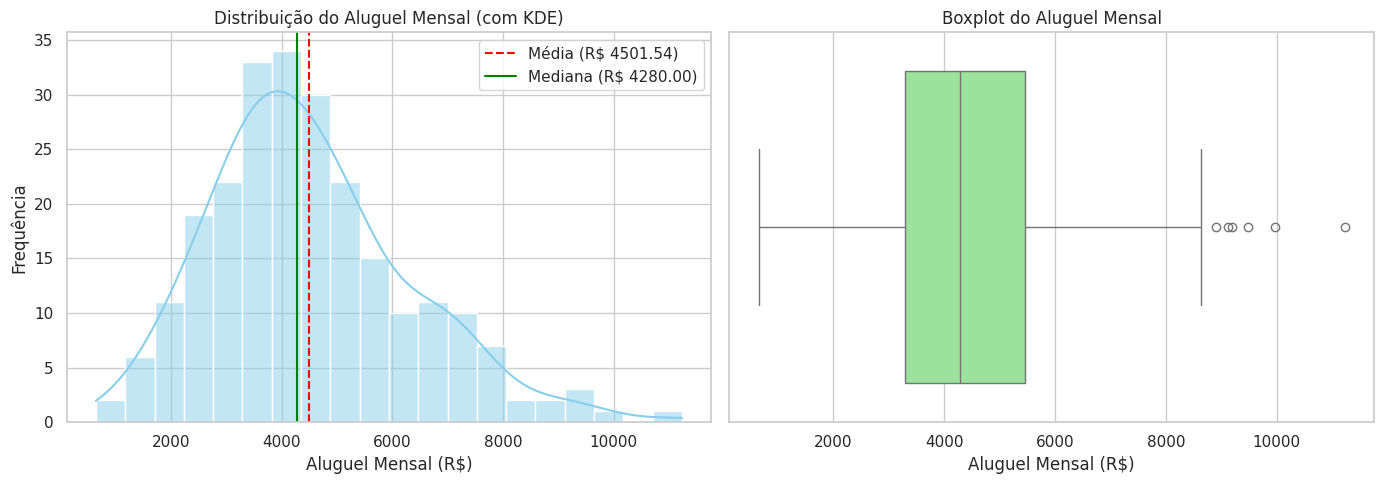

In [13]:
# Métricas e estatísticas de aluguel_mensal_brl
aluguel = df_preparado["aluguel_mensal_brl"]

count = aluguel.count()
media = aluguel.mean()
mediana = aluguel.median()
std = aluguel.std()
assimetria = aluguel.skew()

q1 = aluguel.quantile(0.25)
q3 = aluguel.quantile(0.75)
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

possiveis_outliers = aluguel[(aluguel < limite_inferior) | (aluguel > limite_superior)]

resumo_aluguel = pd.Series({
    "count": count,
    "media": media,
    "mediana": mediana,
    "std": std,
    "assimetria": assimetria,
    "q1": q1,
    "q3": q3,
    "iqr": iqr,
    "limite_inferior": limite_inferior,
    "limite_superior": limite_superior,
    "qtd_outliers": len(possiveis_outliers)
})

print("--- Resumo Estatístico do Aluguel Mensal ---")
display(resumo_aluguel)

# Visualizações
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma com KDE
sns.histplot(aluguel, kde=True, ax=axes[0], color="skyblue", bins=20)
axes[0].axvline(media, color="red", linestyle="--", label=f"Média (R$ {media:.2f})")
axes[0].axvline(mediana, color="green", linestyle="-", label=f"Mediana (R$ {mediana:.2f})")
axes[0].set_title("Distribuição do Aluguel Mensal (com KDE)")
axes[0].set_xlabel("Aluguel Mensal (R$)")
axes[0].set_ylabel("Frequência")
axes[0].legend()

# Boxplot
sns.boxplot(x=aluguel, ax=axes[1], color="lightgreen")
axes[1].set_title("Boxplot do Aluguel Mensal")
axes[1].set_xlabel("Aluguel Mensal (R$)")

plt.tight_layout()
plt.show()


### Interpretação C1 — SUA RESPOSTA

- **Afirmação:** A distribuição do aluguel mensal apresenta assimetria positiva moderada com presença de outliers no extremo superior.
- **Evidência:** A média (R$ 4.501,54) é superior à mediana (R$ 4.280,00), com assimetria de 0,70. O critério de 1,5 × IQR identificou 6 possíveis outliers acima do limite superior de R$ 8.700,00 (aluguéis entre R$ 8.900,00 e R$ 11.200,00).
- **Interpretação:** A maioria dos imóveis concentra-se nas faixas de preço baixas e intermediárias (Q1 = R$ 3.300,00 e Q3 = R$ 5.460,00), enquanto imóveis de altíssimo padrão puxam a média para cima.
- **Limitação:** O número de observações (n = 241) e a natureza sintética da base exigem cautela para não generalizar estes limites de preço diretamente para o mercado imobiliário real.


## C2. Categoria e comparação entre grupos (0,33)

1. Crie uma tabela de frequência absoluta e percentual de `tipo_imovel`.
2. Com `groupby()`, agregue `n`, média, mediana e desvio-padrão de aluguel por tipo.
3. Ordene pela média e crie um boxplot por tipo.
4. Interprete o grupo de maior média considerando também `n` e dispersão.


--- Frequência por Tipo de Imóvel ---


,Absoluta,Percentual (%)
tipo_imovel,,
apartamento,118,48.962656
casa,69,28.630705
studio,24,9.958506
kitnet,19,7.883817
cobertura,11,4.564315



--- Estatísticas do Aluguel por Tipo de Imóvel ---


,n,media,mediana,std
tipo_imovel,,,,
cobertura,11,8040.000000,7580.0,1645.047112
casa,69,5527.536232,5340.0,1499.837644
apartamento,118,4243.305085,4190.0,1302.908682
studio,24,3056.666667,3165.0,654.254748
kitnet,19,2155.789474,2140.0,809.116911


/tmp/ipykernel_10565/1716524159.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


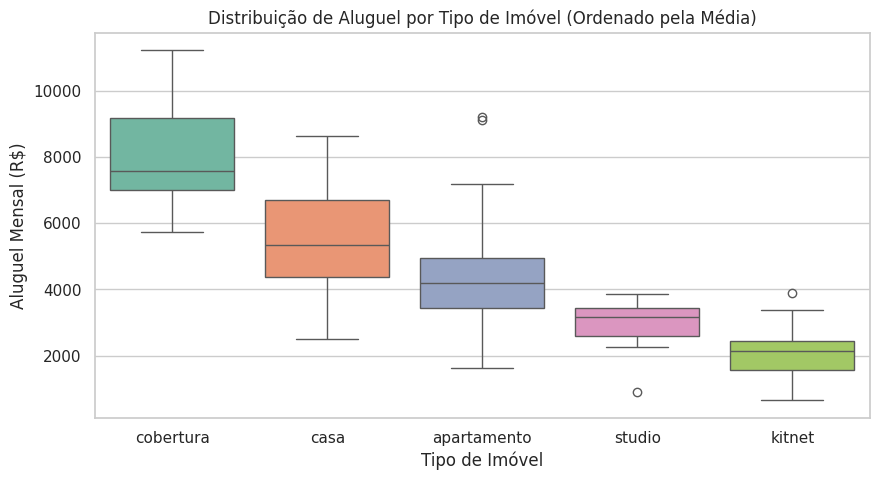

In [14]:
# Tabela de frequência absoluta e percentual
freq_abs = df_preparado["tipo_imovel"].value_counts()
freq_pct = df_preparado["tipo_imovel"].value_counts(normalize=True) * 100
frequencia_tipo = pd.DataFrame({"Absoluta": freq_abs, "Percentual (%)": freq_pct})

# Agregação por tipo_imovel ordenada pela média
aluguel_por_tipo = df_preparado.groupby("tipo_imovel", observed=False)["aluguel_mensal_brl"].agg(
    n="count",
    media="mean",
    mediana="median",
    std="std"
).sort_values(by="media", ascending=False)

print("--- Frequência por Tipo de Imóvel ---")
display(frequencia_tipo)

print("\n--- Estatísticas do Aluguel por Tipo de Imóvel ---")
display(aluguel_por_tipo)

# Boxplot por Tipo de Imóvel
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_preparado,
    x="tipo_imovel",
    y="aluguel_mensal_brl",
    order=aluguel_por_tipo.index,
    palette="Set2"
)
plt.title("Distribuição de Aluguel por Tipo de Imóvel (Ordenado pela Média)")
plt.xlabel("Tipo de Imóvel")
plt.ylabel("Aluguel Mensal (R$)")
plt.show()


### Interpretação C2 — SUA RESPOSTA

- **Afirmação:** As coberturas representam o segmento de maior valor médio de aluguel, enquanto kitnets e studios possuem os menores valores.
- **Evidência:** O grupo "cobertura" possui a maior média (R$ 8.040,00) e mediana (R$ 7.580,00), seguido por casas (média R$ 5.527,54), apartamentos (R$ 4.243,31), studios (R$ 3.056,67) e kitnets (R$ 2.155,79).
- **Interpretação:** Há uma clara hierarquia de preços atrelada à tipologia do imóvel. Contudo, as coberturas exibem amostragem reduzida (n = 11; 4,56% da base) e alto desvio-padrão (R$ 1.645,05), o que amplia a dispersão nesse grupo.
- **Limitação:** A associação entre tipo de imóvel e valor de aluguel não implica causalidade direta isolada, pois variáveis de confusão (como metragem quadrada e padrão construtivo) influenciam simultaneamente ambas as variáveis.

## C3. Relações numéricas, heatmap e Pearson (0,52)

Use apenas as variáveis originais abaixo:

`area_m2`, `quartos`, `banheiros`, `vagas_garagem`, `andar`, `idade_anos`, `distancia_centro_km`, `condominio_mensal_brl`, `iptu_anual_brl`, `aluguel_mensal_brl`.

1. Calcule a matriz de correlação e ordene correlações com o aluguel pelo valor absoluto, removendo a autocorrelação.
2. Crie um heatmap de pelo menos seis variáveis.
3. Crie dois `regplot`: área × aluguel e distância × aluguel.
4. Calcule Pearson e valor de p para área × aluguel.
5. Interprete direção, força e limites sem concluir causalidade.


--- Correlações com o Aluguel Mensal (Ordenadas por Valor Absoluto) ---


,r_aluguel
iptu_anual_brl,0.839901
area_m2,0.810573
banheiros,0.745563
quartos,0.740373
vagas_garagem,0.622088
condominio_mensal_brl,0.215714
distancia_centro_km,-0.186896
andar,-0.162324
idade_anos,0.012169


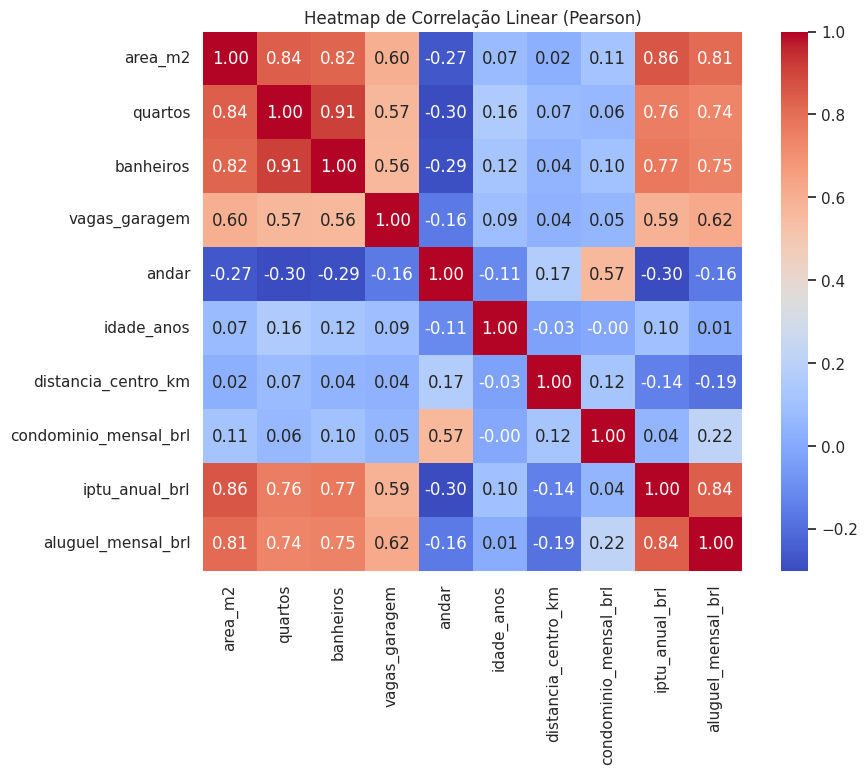

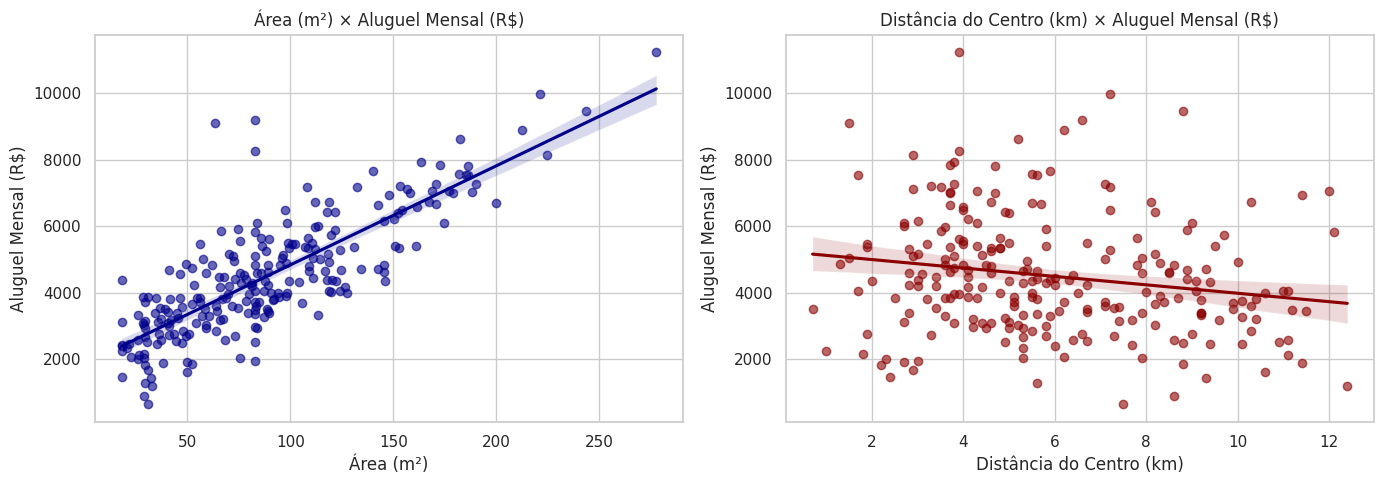

--- Coeficiente de Pearson (Área × Aluguel) ---
Coeficiente r: 0.8106
p-valor: 1.8442e-57


In [15]:
variaveis_numericas = [
    "area_m2", "quartos", "banheiros", "vagas_garagem", "andar",
    "idade_anos", "distancia_centro_km", "condominio_mensal_brl",
    "iptu_anual_brl", "aluguel_mensal_brl",
]

# 1.
matriz_corr = df_preparado[variaveis_numericas].corr()
correlacoes_aluguel = matriz_corr["aluguel_mensal_brl"].drop("aluguel_mensal_brl")
correlacoes_aluguel = correlacoes_aluguel.reindex(
    correlacoes_aluguel.abs().sort_values(ascending=False).index
)

print("--- Correlações com o Aluguel Mensal (Ordenadas por Valor Absoluto) ---")
display(correlacoes_aluguel.to_frame(name="r_aluguel"))

# 2.
plt.figure(figsize=(10, 7))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)
plt.title("Heatmap de Correlação Linear (Pearson)")
plt.show()

# 3.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(data=df_preparado, x="area_m2", y="aluguel_mensal_brl", ax=axes[0], color="darkblue", scatter_kws={"alpha":0.6})
axes[0].set_title("Área (m²) × Aluguel Mensal (R$)")
axes[0].set_xlabel("Área (m²)")
axes[0].set_ylabel("Aluguel Mensal (R$)")

sns.regplot(data=df_preparado, x="distancia_centro_km", y="aluguel_mensal_brl", ax=axes[1], color="darkred", scatter_kws={"alpha":0.6})
axes[1].set_title("Distância do Centro (km) × Aluguel Mensal (R$)")
axes[1].set_xlabel("Distância do Centro (km)")
axes[1].set_ylabel("Aluguel Mensal (R$)")

plt.tight_layout()
plt.show()

# 4.
resultado_pearson = stats.pearsonr(df_preparado["area_m2"], df_preparado["aluguel_mensal_brl"])
print(f"--- Coeficiente de Pearson (Área × Aluguel) ---")
print(f"Coeficiente r: {resultado_pearson.statistic:.4f}")
print(f"p-valor: {resultado_pearson.pvalue:.4e}")


### Interpretação C3 — SUA RESPOSTA

- **Variável de maior correlação absoluta:** `iptu_anual_brl` (r = 0,84), seguida de perto por `area_m2` (r = 0,81).
- **Interpretação de Pearson (Área × Aluguel):** O coeficiente de Pearson indica uma associação linear positiva muito forte (r = 0,81, p = 1,84e-57). Como o valor de p é expressivamente inferior a 0,05, a relação é estatisticamente significante.
- **Direção e Força:** Imóveis com maior dimensão física tendem a apresentar valores de aluguel substancialmente mais elevados. Por outro lado, a distância do centro apresenta uma fraca correlação negativa com o valor do aluguel (r = -0,19).
- **Por que não prova causalidade nem importância prática:** A correlação mede apenas a associação linear contemporânea entre duas variáveis. O valor de p atesta unicamente a probabilidade de a associação observada não ser fruto de mero acaso amostral, não garantindo que a área seja a causa direta do aumento do preço (que depende de fatores de mercado, localização e acabamento) nem determinando utilidade prática sem análise de custos.


## C4. Categórica × categórica: contingência e qui-quadrado (0,28)

Crie uma tabela de contingência entre `aceita_pet` e `tipo_imovel`. Calcule qui-quadrado, graus de liberdade, valor de p e a menor frequência esperada. Interprete com cautela se houver frequência esperada pequena.


In [16]:
tabela_contingencia = pd.crosstab(df_preparado["aceita_pet"], df_preparado["tipo_imovel"])

chi2, p_value_chi2, graus_liberdade, esperadas = stats.chi2_contingency(tabela_contingencia)
esperadas_df = pd.DataFrame(esperadas, index=tabela_contingencia.index, columns=tabela_contingencia.columns)

print("--- Tabela de Contingência (Frequências Observadas) ---")
display(tabela_contingencia)

print("\n--- Frequências Esperadas ---")
display(esperadas_df.round(2))

print("--- Resultados do Teste Qui-Quadrado ---")
print(f"Estatística Qui-Quadrado (χ²): {chi2:.4f}")
print(f"Graus de Liberdade: {graus_liberdade}")
print(f"p-valor: {p_value_chi2:.4f}")
print(f"Menor Frequência Esperada: {esperadas.min():.2f}")

--- Tabela de Contingência (Frequências Observadas) ---


tipo_imovel,apartamento,casa,cobertura,kitnet,studio
aceita_pet,,,,,
nao,50,15,5,12,7
sim,68,54,6,7,17



--- Frequências Esperadas ---


tipo_imovel,apartamento,casa,cobertura,kitnet,studio
aceita_pet,,,,,
nao,43.58,25.48,4.06,7.02,8.86
sim,74.42,43.52,6.94,11.98,15.14


--- Resultados do Teste Qui-Quadrado ---
Estatística Qui-Quadrado (χ²): 14.9128
Graus de Liberdade: 4
p-valor: 0.0049
Menor Frequência Esperada: 4.06


### Interpretação C4 — SUA RESPOSTA

- **O que o teste investiga:** O teste Qui-Quadrado investiga a existência de associação estatística entre as variáveis categóricas `aceita_pet` e `tipo_imovel`, testando a hipótese nula de independência entre elas.
- **Resultado estatístico:** Com χ² = 14,91, 4 graus de liberdade e p-valor = 0,0049 (inferior ao nível de significância de 5%), rejeita-se a hipótese nula de independência.
- **O que o p-valor não informa:** O p-valor não quantifica a força ou a magnitude prática da associação entre a aceitação de pets e o tipo de imóvel, apenas indica que a distribuição conjunta observada difere significativamente do modelo de independência estocástica.
- **Impacto da menor frequência esperada:** A menor frequência esperada obtida foi 4,06 (no grupo Cobertura sem pet). Por ser inferior a 5, há uma ligeira violação das premissas clássicas do teste de Qui-Quadrado, o que sugere cautela na interpretação da aproximação assintótica, sendo recomendável em auditorias o uso do Teste Exato de Fisher ou agrupamento de categorias pequenas.


## C5. Multivariada, insights e exportação (0,47)

1. Crie um `scatterplot` de área × aluguel com `hue='mobilia'`.
2. Dê ao gráfico um título que funcione como conclusão provisória.
3. Escreva **dois insights completos** no formato afirmação — evidência — interpretação — limitação.
4. Crie `resumo_eda` e exporte-o, junto com `aluguel_por_tipo` e `correlacoes_aluguel`, usando a matrícula no nome.


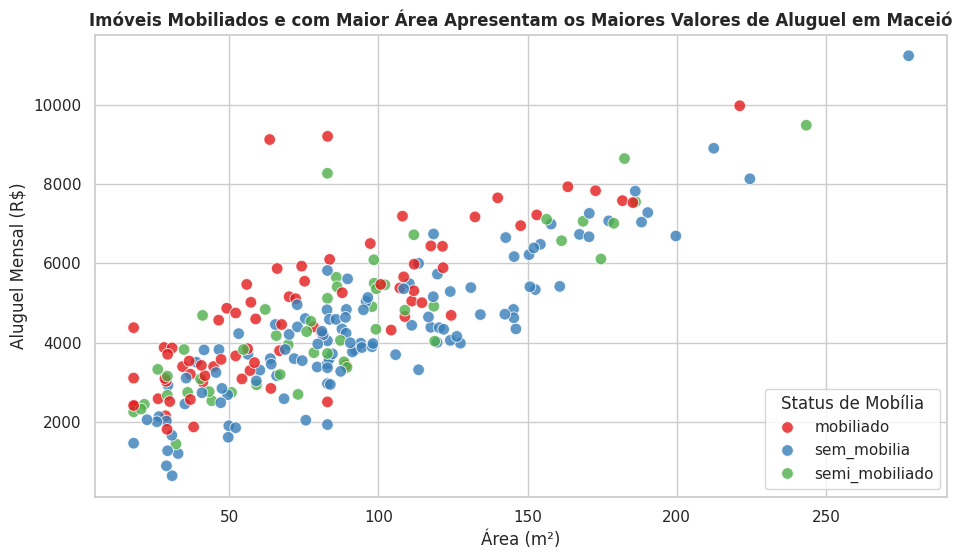

In [17]:
# Scatterplot multivariado
plt.figure(figsize=(11, 6))
sns.scatterplot(
    data=df_preparado,
    x="area_m2",
    y="aluguel_mensal_brl",
    hue="mobilia",
    palette="Set1",
    s=70,
    alpha=0.8
)

plt.title("Imóveis Mobiliados e com Maior Área Apresentam os Maiores Valores de Aluguel em Maceió", fontsize=12, fontweight="bold")
plt.xlabel("Área (m²)")
plt.ylabel("Aluguel Mensal (R$)")
plt.legend(title="Status de Mobília")
plt.show()


### Insights finais — SUA RESPOSTA

**Insight 1 — Afirmação:** A dimensão física do imóvel (`area_m2`) é o principal determinante quantitativo do valor de locação.  
**Evidência:** O coeficiente de correlação de Pearson é r = 0,81 (p = 1,84e-57), demonstrando uma relação linear positiva forte e estatisticamente significante.  
**Interpretação:** Imóveis maiores demandam custos operacionais e de aquisição mais elevados, repassando esse valor sob a forma de aluguel mensal acrescido.  
**Limitação:** A relação apresenta dispersão em metragens elevadas, indicando que acabamento e localização moderam o preço por metro quadrado.  

**Insight 2 — Afirmação:** A presença de mobília atua como um fator valorizador secundário em relação à metragem.  
**Evidência:** No gráfico multivariado, imóveis marcados como `mobiliado` tendem a situar-se na borda superior da distribuição de preços para faixas equivalentes de `area_m2`.  
**Interpretação:** A conveniência da mobília embutida permite que proprietários cobrem um prêmio de valor sobre o aluguel sem necessidade de aumentar a área física.  
**Limitação:** O estado de conservação e a qualidade da mobília não estão mensurados na base, impedindo estimar com precisão o retorno individual do mobiliário.

In [18]:
# Criação do DataFrame resumo_eda
resumo_eda = pd.DataFrame([
    {"analise": "Univariada Aluguel", "descoberta_chave": "Média R$ 4.501,54 e Mediana R$ 4.280,00 com assimetria de 0,70 e 6 outliers acima de R$ 8.700,00."},
    {"analise": "Bivariada Tipo x Aluguel", "descoberta_chave": "Coberturas lideram maior preço médio (R$ 8.040,00) e Kitnets o menor (R$ 2.155,79)."},
    {"analise": "Bivariada Area x Aluguel", "descoberta_chave": "Correlação de Pearson forte e positiva (r = 0,81, p < 0,001)."},
    {"analise": "Categorias Pet x Tipo", "descoberta_chave": "Teste Qui-Quadrado estatisticamente significante (χ² = 14,91, p = 0,0049)."},
    {"analise": "Multivariada Area x Aluguel x Mobilia", "descoberta_chave": "Imóveis mobiliados possuem preços superiores para áreas equivalentes."}
])

# Nomes dos arquivos de exportação
nome_resumo_eda = f"resumo_eda_{MATRICULA}.csv"
nome_aluguel_tipo = f"aluguel_por_tipo_{MATRICULA}.csv"
nome_correlacoes = f"correlacoes_aluguel_{MATRICULA}.csv"

# Exportação em formato CSV
resumo_eda.to_csv(nome_resumo_eda, index=False, sep=";")
aluguel_por_tipo.to_csv(nome_aluguel_tipo, sep=";")
correlacoes_aluguel.to_frame(name="r_aluguel").to_csv(nome_correlacoes, sep=";")

print("✓ Exportação da Parte C concluída com sucesso!")
print(f"Arquivos gerados: {nome_resumo_eda}, {nome_aluguel_tipo}, {nome_correlacoes}")


✓ Exportação da Parte C concluída com sucesso!
Arquivos gerados: resumo_eda_2025102151.csv, aluguel_por_tipo_2025102151.csv, correlacoes_aluguel_2025102151.csv


# Parte D — Evidências de execução e reprodutibilidade (0,5 ponto)

Esta parte verifica se o notebook foi executado sobre a base correta e se você compreende as próprias decisões. Ela **não é um detector de IA**.

## D1. Amostra individual (0,15)

Execute a célula. Depois escolha **um** dos cinco códigos e escreva duas observações específicas, citando valores reais do registro.


In [19]:
amostra_individual = df_original.sample(5, random_state=SEMENTE_INDIVIDUAL)
display(amostra_individual)
print("Códigos da amostra:", amostra_individual["codigo_imovel"].tolist())


,codigo_imovel,cidade,bairro,tipo_imovel,mobilia,aceita_pet,area_m2,quartos,banheiros,vagas_garagem,andar,idade_anos,distancia_centro_km,condominio_mensal_brl,iptu_anual_brl,aluguel_mensal_brl
196,IMV-0197,Maceio,Ponta Verde,casa,sem_mobilia,sim,96.5,3,3,1,0,14.0,4.4,0.00,2763.40,5140.0
192,IMV-0193,Maceio,Cruz das Almas,apartamento,mobiliado,sim,117.6,4,4,2,10,27.0,8.2,638.91,2711.52,6440.0
55,IMV-0056,Maceio,Jatiuca,casa,semi_mobiliado,nao,186.2,5,4,2,0,29.0,1.7,260.00,NaN,7550.0
71,IMV-0072,Maceio,Mangabeiras,casa,sem_mobilia,nao,29.5,2,2,0,0,34.0,5.0,350.00,2000.94,2930.0
167,IMV-0168,Maceio,Farol,apartamento,semi_mobiliado,sim,50.8,3,2,1,7,35.0,1.9,NaN,1311.06,2750.0


Códigos da amostra: ['IMV-0197', 'IMV-0193', 'IMV-0056', 'IMV-0072', 'IMV-0168']


### Resposta D1 — SUA RESPOSTA

- **Código escolhido:** `IMV-0197`
- **Observação específica 1:** O imóvel é uma casa localizada no bairro Ponta Verde com área de 96,5 m² e aluguel mensal de R$ 5.140,00.
- **Observação específica 2:** Não apresentava valores ausentes na base bruta e possui 3 quartos, 2 banheiros e 2 vagas de garagem.


## D2. Caso de auditoria antes/depois (0,20)

A célula seleciona, de modo reproduzível pela matrícula, um caso que apresentava ao menos um problema de qualidade. Compare a versão bruta e a preparada. Se o caso tiver sido removido, a saída preparada ficará vazia — isso também precisa ser explicado.


In [20]:
mascara_auditoria = (
    df_original.isna().any(axis=1)
    | df_original.duplicated(keep=False)
    | df_original["area_m2"].le(0)
    | df_original["distancia_centro_km"].lt(0)
    | df_original["mobilia"].dropna().reindex(df_original.index).ne(
        df_original["mobilia"].dropna().reindex(df_original.index).str.strip()
    ).fillna(False)
)
casos_auditoria = sorted(df_original.loc[mascara_auditoria, "codigo_imovel"].unique())
codigo_auditoria = casos_auditoria[SEMENTE_INDIVIDUAL % len(casos_auditoria)]

print("Código sorteado:", codigo_auditoria)
print("ANTES")
display(df_original.loc[df_original["codigo_imovel"].eq(codigo_auditoria)])
print("DEPOIS")
display(df_preparado.loc[df_preparado["codigo_imovel"].eq(codigo_auditoria)])


Código sorteado: IMV-0157
ANTES


,codigo_imovel,cidade,bairro,tipo_imovel,mobilia,aceita_pet,area_m2,quartos,banheiros,vagas_garagem,andar,idade_anos,distancia_centro_km,condominio_mensal_brl,iptu_anual_brl,aluguel_mensal_brl
156,IMV-0157,Maceio,Mangabeiras,studio,mobiliado,sim,37.0,1,1,1,8,15.0,4.2,291.36,NaN,3210.0


DEPOIS


,codigo_imovel,cidade,bairro,tipo_imovel,mobilia,aceita_pet,area_m2,quartos,banheiros,vagas_garagem,andar,idade_anos,distancia_centro_km,condominio_mensal_brl,iptu_anual_brl,aluguel_mensal_brl,area_ft2,area_minmax,area_zscore,faixa_aluguel,mobilia_mobiliado,mobilia_sem_mobilia,mobilia_semi_mobiliado
156,IMV-0157,Maceio,Mangabeiras,studio,mobiliado,sim,37.0,1,1,1,8,15.0,4.2,291.36,2000.94,3210.0,398.2643,0.073161,-1.057986,medio,1,0,0


### Resposta D2 — SUA RESPOSTA

- **Problema observado no registro bruto:** O registro do imóvel `IMV-0157` apresentava valor ausente (`NaN`) na coluna `iptu_anual_brl`.
- **Ação realizada pelo seu pipeline:** O pipeline realizou a imputação do valor ausente utilizando a mediana do campo `iptu_anual_brl` calculada sobre os dados válidos da base.
- **Evidência antes/depois:** No registro bruto (ANTES), a coluna `iptu_anual_brl` constava como `NaN`. Após o tratamento (DEPOIS), o campo foi preenchido com o valor `2000.94`.
- **Possível impacto da decisão:** Preservou-se o registro no conjunto de dados sem descartar a observação inteira, permitindo seu uso em análises multivariadas ao custo de assumir o valor mediano para o imposto predial.


## D3. Assinatura da execução (0,15)

A assinatura combina matrícula e resultados finais. Ela confirma consistência e reprodutibilidade, mas não prova autoria.


In [21]:
assinatura_execucao = (
    int(round(df_preparado["aluguel_mensal_brl"].sum()))
    ^ SEMENTE_INDIVIDUAL
    ^ (len(df_preparado) * 1009)
) % 10_000_000
print(f"ASSINATURA-{assinatura_execucao:07d}")


ASSINATURA-3871328


## Checklist final

- [ ] identificação e declaração preenchidas;
- [ ] importação validada por forma e hash;
- [ ] diagnóstico inicial exportado;
- [ ] base bruta preservada;
- [ ] ausências, duplicatas, texto e domínio tratados;
- [ ] unidade, normalização, binning e one-hot encoding realizados;
- [ ] diagnóstico antes/depois e registro de decisões apresentados;
- [ ] EDA univariada, bivariada e multivariada concluída;
- [ ] Pearson e qui-quadrado interpretados sem causalidade indevida;
- [ ] dois insights com evidência e limitação;
- [ ] amostra, caso de auditoria e assinatura executados;
- [ ] notebook reiniciado e executado do início ao fim;
- [ ] notebook e seis CSVs entregues com a matrícula no nome.

## Sobre a base

Base sintética, gerada com semente fixa para esta avaliação. Os locais são usados apenas como rótulos didáticos; os registros, valores e relações não descrevem o mercado imobiliário real.
